In [1]:
from pathlib import Path
from IPython.display import display, Markdown

from resources.imports import *
try:
    import torch
except ModuleNotFoundError:
    torch = None

from resources.MLmetrics import (
    postprocess_list_runs,
    postprocess_artifact_table,
    postprocess_load_curve_run,
    postprocess_curve_run_overview,
    display_curve_run_overview,
    postprocess_build_active_curve_diagnostics,
    curve_summary_table,
    print_curve_diagnostics,
    display_curve_main_dashboard,
    display_curve_pointwise_summary,
    display_curve_sample_error_summary,
    display_curve_peak_energy_summary,
    display_curve_zone_summary,
    display_curve_sample_examples,
    display_curve_loss_component_breakdown,
    plot_curve_all_point_parity,
    display_curve_initial_slope_summary,
    plot_loss_history,
)

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.grid": False,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


In [2]:
%load_ext autoreload
%autoreload 2


## 1. Find Recent Runs


In [17]:
FIND_RUN = True
RUN_ROOT = Path(r"Z:/p2")
MAX_RECENT_RUNS = 25


if FIND_RUN:
    recent_runs = postprocess_list_runs(RUN_ROOT, max_runs=MAX_RECENT_RUNS, include_hpo=True)
    display(recent_runs)
    if recent_runs.empty:
        raise ValueError("No saved runs were found. Set RUN_PATH manually.")


,task,output_kind,model,run_name,run_dir,model_json,model_mdl,results_dir,is_hpo,modified
0,UT,FieldToCurve,Transformer,Field2Curve-1,Z:\p2\UT\FieldToCurve\Transformer\Field2Curve-1,Z:\p2\UT\FieldToCurve\Transformer\Field2Curve-...,Z:\p2\UT\FieldToCurve\Transformer\Field2Curve-...,Z:\p2\UT\FieldToCurve\Transformer\Field2Curve-...,False,2026-06-10 16:11:44
1,FT,Curve,MLP,CurveFT_fullHPO,Z:\p2\FT\Curve\HPO\CurveFT_fullHPO\MLP,Z:\p2\FT\Curve\HPO\CurveFT_fullHPO\MLP\best_mo...,Z:\p2\FT\Curve\HPO\CurveFT_fullHPO\MLP\best_mo...,Z:\p2\FT\Curve\HPO\CurveFT_fullHPO\MLP\best_mo...,True,2026-06-09 18:56:42
2,FT,Curve,GAT,CurveFT_fullHPO,Z:\p2\FT\Curve\HPO\CurveFT_fullHPO\GAT,Z:\p2\FT\Curve\HPO\CurveFT_fullHPO\GAT\best_mo...,Z:\p2\FT\Curve\HPO\CurveFT_fullHPO\GAT\best_mo...,Z:\p2\FT\Curve\HPO\CurveFT_fullHPO\GAT\best_mo...,True,2026-06-09 18:56:42
3,FT,Curve,GCN,CurveFT_fullHPO,Z:\p2\FT\Curve\HPO\CurveFT_fullHPO\GCN,Z:\p2\FT\Curve\HPO\CurveFT_fullHPO\GCN\best_mo...,Z:\p2\FT\Curve\HPO\CurveFT_fullHPO\GCN\best_mo...,Z:\p2\FT\Curve\HPO\CurveFT_fullHPO\GCN\best_mo...,True,2026-06-09 18:56:42
4,FT,Curve,Transformer,CurveFT_fullHPO,Z:\p2\FT\Curve\HPO\CurveFT_fullHPO\Transformer,Z:\p2\FT\Curve\HPO\CurveFT_fullHPO\Transformer...,Z:\p2\FT\Curve\HPO\CurveFT_fullHPO\Transformer...,Z:\p2\FT\Curve\HPO\CurveFT_fullHPO\Transformer...,True,2026-06-09 18:56:40
5,UT,Curve,GAT,CurveUT_fullHPO,Z:\p2\UT\Curve\HPO\CurveUT_fullHPO\GAT,Z:\p2\UT\Curve\HPO\CurveUT_fullHPO\GAT\best_mo...,Z:\p2\UT\Curve\HPO\CurveUT_fullHPO\GAT\best_mo...,Z:\p2\UT\Curve\HPO\CurveUT_fullHPO\GAT\best_mo...,True,2026-06-09 18:56:14
6,UT,Curve,GCN,CurveUT_fullHPO,Z:\p2\UT\Curve\HPO\CurveUT_fullHPO\GCN,Z:\p2\UT\Curve\HPO\CurveUT_fullHPO\GCN\best_mo...,Z:\p2\UT\Curve\HPO\CurveUT_fullHPO\GCN\best_mo...,Z:\p2\UT\Curve\HPO\CurveUT_fullHPO\GCN\best_mo...,True,2026-06-09 18:56:14
7,UT,Curve,Transformer,CurveUT_fullHPO,Z:\p2\UT\Curve\HPO\CurveUT_fullHPO\Transformer,Z:\p2\UT\Curve\HPO\CurveUT_fullHPO\Transformer...,Z:\p2\UT\Curve\HPO\CurveUT_fullHPO\Transformer...,Z:\p2\UT\Curve\HPO\CurveUT_fullHPO\Transformer...,True,2026-06-09 18:56:12
8,UT,Curve,MLP,CurveUT_fullHPO,Z:\p2\UT\Curve\HPO\CurveUT_fullHPO\MLP,Z:\p2\UT\Curve\HPO\CurveUT_fullHPO\MLP\best_mo...,Z:\p2\UT\Curve\HPO\CurveUT_fullHPO\MLP\best_mo...,Z:\p2\UT\Curve\HPO\CurveUT_fullHPO\MLP\best_mo...,True,2026-06-09 18:56:12
9,Akash,NaN,FCC_disNodes_dN-0.2_data-in_nSims-all_split-fr...,mlp,Z:\p2\Akash\FCC_disNodes_dN-0.2_data-in_nSims-...,Z:\p2\Akash\FCC_disNodes_dN-0.2_data-in_nSims-...,Z:\p2\Akash\FCC_disNodes_dN-0.2_data-in_nSims-...,Z:\p2\Akash\FCC_disNodes_dN-0.2_data-in_nSims-...,False,2026-05-06 19:54:10


## 2. User Configuration


In [4]:
mechMode = "UT"
output_kind = "FieldToCurve"
model = "Transformer"
run_name = "Field2Curve-1"
VIEW_MODE = "UT"
run_type = "standard"  # "standard", "model_hpo", or "cross_model_hpo"
RUN_PATH_OVERRIDE = None


if RUN_PATH_OVERRIDE is not None:
    RUN_PATH = Path(RUN_PATH_OVERRIDE)
elif run_type == "standard":
    RUN_PATH = RUN_ROOT / mechMode / output_kind / model / run_name
elif run_type == "model_hpo":
    RUN_PATH = RUN_ROOT / mechMode / output_kind / model / "HPO" / run_name
elif run_type == "cross_model_hpo":
    RUN_PATH = RUN_ROOT / mechMode / output_kind / "HPO" / run_name / model
else:
    raise ValueError("run_type must be 'standard', 'model_hpo', or 'cross_model_hpo'.")

DATA_PATH_OVERRIDE = None
PREFER_HPO_BEST = True
ZONE_BOUNDARIES = None

if VIEW_MODE is None:
    VIEW_MODE = mechMode if str(mechMode).upper() in ["UT", "FT"] else "UT"
VIEW_MODE = str(VIEW_MODE).upper()
if VIEW_MODE not in ["UT", "FT"]:
    raise ValueError("VIEW_MODE must be UT or FT. For MULTI runs, choose which output branch to view.")

LOAD_DATA = False
LOAD_MODEL = False
DEVICE = "cuda" if torch is not None and torch.cuda.is_available() else "cpu"

ACTIVE_SPLIT = "test"


## 3. Load Run Artifacts


In [5]:
ARTIFACT_TABLE_KEYS = None


artifacts, loaded, DAT, MOD = postprocess_load_curve_run(
    RUN_PATH,
    run_root=RUN_ROOT,
    prefer_hpo_best=PREFER_HPO_BEST,
    load_data=LOAD_DATA,
    load_model=LOAD_MODEL,
    data_path_override=DATA_PATH_OVERRIDE,
    device=DEVICE,
)


display(postprocess_artifact_table(artifacts, keys=ARTIFACT_TABLE_KEYS))
for warning in artifacts.get("warnings", []):
    print("WARNING:", warning)


,artifact,path_or_value
0,input_path,Z:\p2\UT\FieldToCurve\Transformer\Field2Curve-1
1,run_dir,Z:\p2\UT\FieldToCurve\Transformer\Field2Curve-1
2,model_json,Z:\p2\UT\FieldToCurve\Transformer\Field2Curve-...
3,model_mdl,Z:\p2\UT\FieldToCurve\Transformer\Field2Curve-...
4,data_json,Z:\p2\UT\FieldToCurve\Transformer\Field2Curve-...
5,results_dir,Z:\p2\UT\FieldToCurve\Transformer\Field2Curve-...
6,metrics_json,Z:\p2\UT\FieldToCurve\Transformer\Field2Curve-...
7,predictions_npz,Z:\p2\UT\FieldToCurve\Transformer\Field2Curve-...
8,loss_history_csv,Z:\p2\UT\FieldToCurve\Transformer\Field2Curve-...
9,diagnostics_summary_json,Z:\p2\UT\FieldToCurve\Transformer\Field2Curve-...


## 4. Run Setup And Available Outputs


In [6]:
SHOW_RUN_OVERVIEW = True


overview = postprocess_curve_run_overview(
    artifacts,
    loaded,
    data=DAT,
    run_name=run_name,
    run_type=run_type,
    mech_mode=mechMode,
    view_mode=VIEW_MODE,
    model_name=model,
    device=DEVICE,
    active_split=ACTIVE_SPLIT,
)


available_evals = overview["available_evals"]
available_curve_evals = overview["available_curve_evals"]
ACTIVE_SPLIT = overview["active_split"]

if SHOW_RUN_OVERVIEW:
    display_curve_run_overview(overview)
print("mechMode:", mechMode)
print("VIEW_MODE:", VIEW_MODE)
print("ACTIVE_SPLIT:", ACTIVE_SPLIT)


,item,value
0,run,Field2Curve-1
1,run_type,standard
2,mechMode,UT
3,VIEW_MODE,UT
4,model,Transformer
5,output_kind,fieldtocurve
6,device,cpu
7,evaluation_split,test
8,is_hpo,False
9,model_json,Z:\p2\UT\FieldToCurve\Transformer\Field2Curve-...


### Saved Metrics For Active View

,metric,value
0,UT_best_epoch,19
1,UT_best_loss,0.029614
2,UT_best_mse,0.029614
3,UT_best_rmse,"[False, 0.17208793933707023]"
4,UT_mae,1.000389
5,UT_mse,2.758365
6,UT_rmse,1.660833
7,UT_best,615
8,UT_worst,690


### Available Curve Predictions / Diagnostic Tables

,mode,split,outputs,truth,sample_metrics,point_metrics,zone_metrics
0,UT,test,True,True,True,True,True


No HPO files were found for this run.
mechMode: UT
VIEW_MODE: UT
ACTIVE_SPLIT: test


## 5. Build Active Curve Diagnostics


In [7]:
PRINT_ACTIVE_DIAGNOSTICS = True


diagnostics, active_key, active_diag = postprocess_build_active_curve_diagnostics(
    DAT,
    loaded,
    available_evals,
    view_mode=VIEW_MODE,
    active_split=ACTIVE_SPLIT,
    model=MOD,
    zone_boundaries=ZONE_BOUNDARIES,
)


if active_diag is None:
    print("No active diagnostics are available. Check predictions.npz, diagnostic CSVs, VIEW_MODE, or ACTIVE_SPLIT.")
elif PRINT_ACTIVE_DIAGNOSTICS:
    print_curve_diagnostics(active_diag, label=f"{active_key[0]} {active_key[1]}")


UT TEST prediction diagnostics | collapse ratio: 0.93 | RMSE: 1.661 | mean-curve RMSE: 4.49 | skill vs mean curve: 0.63 | peak corr: 0.681 | energy corr: 0.972 | sample curve corr: 0.998
UT TEST zones | elastic: collapse 0.735, RMSE 0.4905 | peak_region: collapse 0.949, RMSE 2.623 | post_peak: collapse 0.92, RMSE 1.075


## 6. Active Diagnostic Summary


In [8]:
SUMMARY_METRICS = [
    "rmse",
    "mae",
    "mse",
    "bias",
    "r2_global",
    "collapse_ratio",
    "mean_curve_baseline_rmse",
    "skill_vs_mean_curve_rmse",
    "mean_sample_curve_corr",
    "peak_corr",
    "peak_x_corr",
    "energy_corr",
    "n_samples",
    "n_points",
]


if active_diag is None:
    print("No active diagnostics are available.")
else:
    display(curve_summary_table(active_diag, metrics=SUMMARY_METRICS))


,metric,value
0,rmse,1.660833
1,mae,1.000389
2,mse,2.758365
3,bias,0.058858
4,r2_global,0.994880
5,collapse_ratio,0.930186
6,mean_curve_baseline_rmse,4.490365
7,skill_vs_mean_curve_rmse,0.630134
8,mean_sample_curve_corr,0.997803
9,peak_corr,0.681090


## 7. Main Curve Diagnostic Dashboard


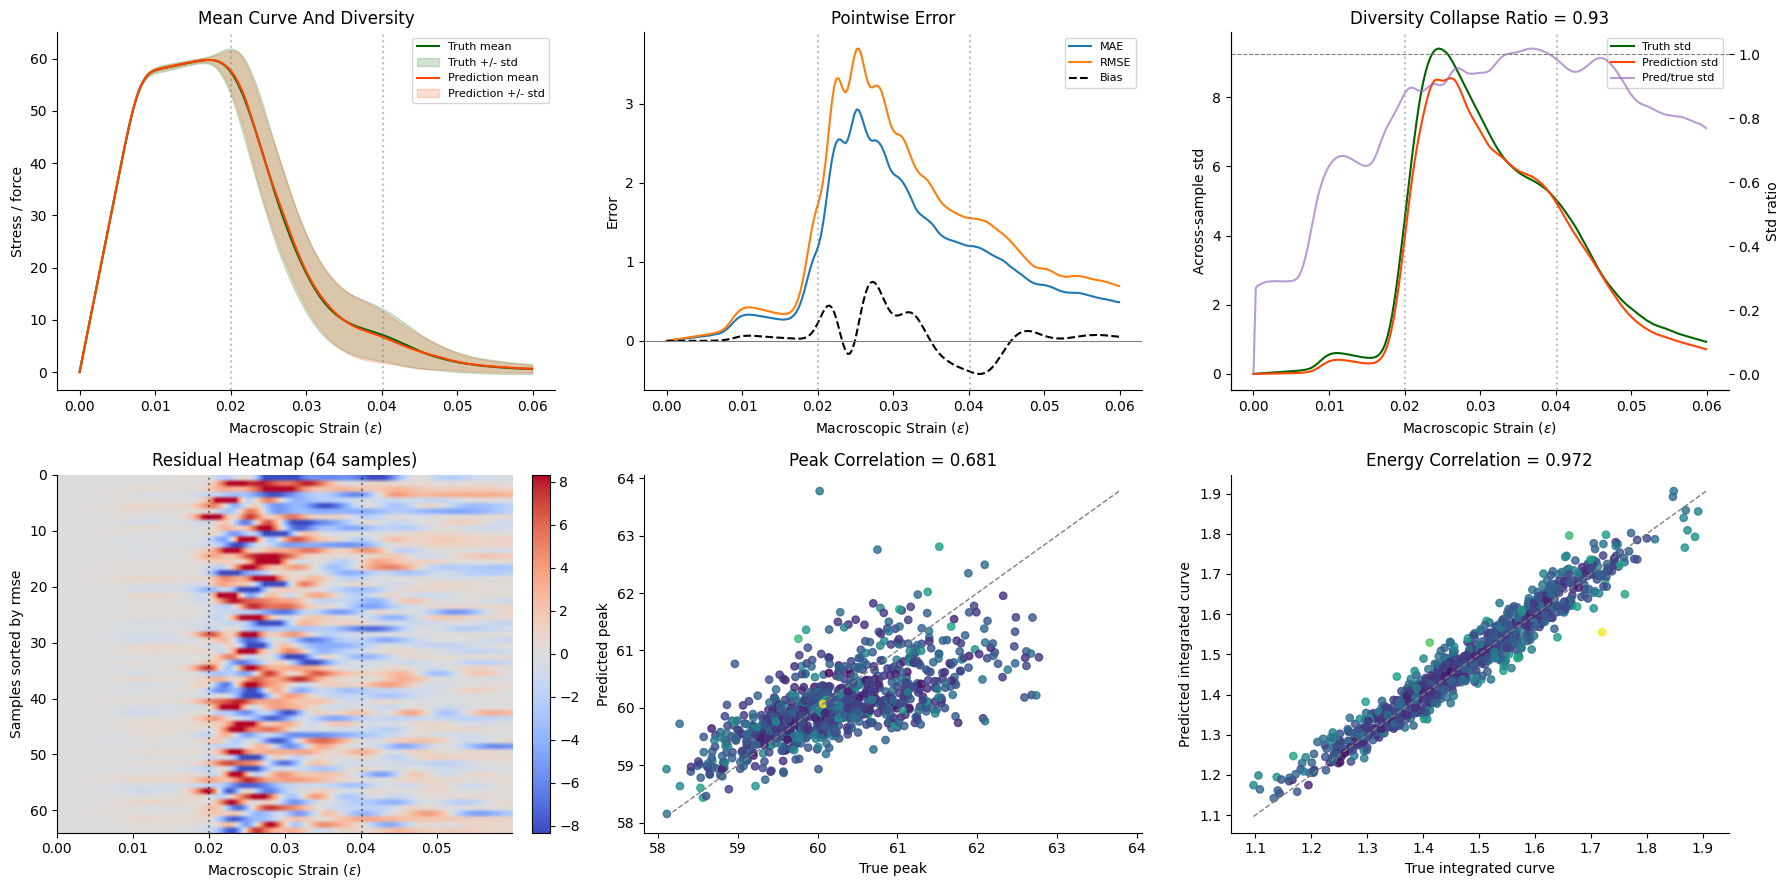

(<Figure size 1800x900 with 8 Axes>,
 array([[<Axes: title={'center': 'Mean Curve And Diversity'}, xlabel='Macroscopic Strain ($\\epsilon$)', ylabel='Stress / force'>,
         <Axes: title={'center': 'Pointwise Error'}, xlabel='Macroscopic Strain ($\\epsilon$)', ylabel='Error'>,
         <Axes: title={'center': 'Diversity Collapse Ratio = 0.93'}, xlabel='Macroscopic Strain ($\\epsilon$)', ylabel='Across-sample std'>],
        [<Axes: title={'center': 'Residual Heatmap (64 samples)'}, xlabel='Macroscopic Strain ($\\epsilon$)', ylabel='Samples sorted by rmse'>,
         <Axes: title={'center': 'Peak Correlation = 0.681'}, xlabel='True peak', ylabel='Predicted peak'>,
         <Axes: title={'center': 'Energy Correlation = 0.972'}, xlabel='True integrated curve', ylabel='Predicted integrated curve'>]],
       dtype=object))

In [9]:
DASHBOARD_MAX_SAMPLES = 64
DASHBOARD_SORT_BY = "rmse"


display_curve_main_dashboard(
    active_diag,
    data=DAT,
    mode=active_key[0] if active_key is not None else VIEW_MODE,
    max_samples=DASHBOARD_MAX_SAMPLES,
    sort_by=DASHBOARD_SORT_BY,
)


## 8. Pointwise Error And Correlations


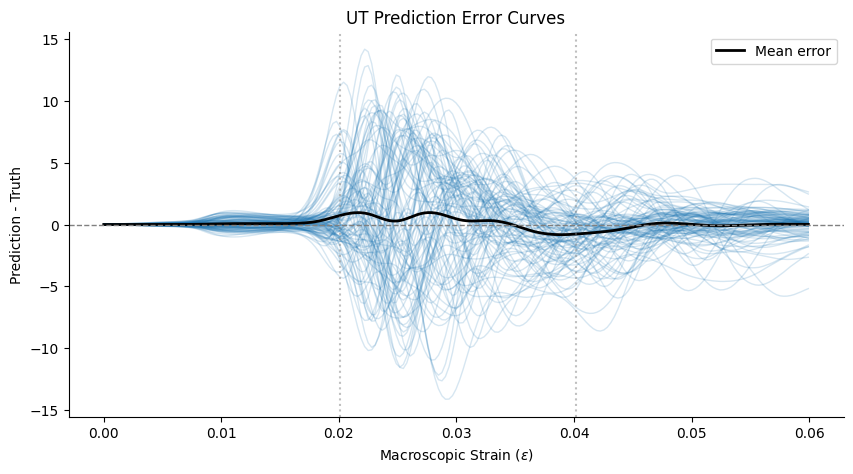

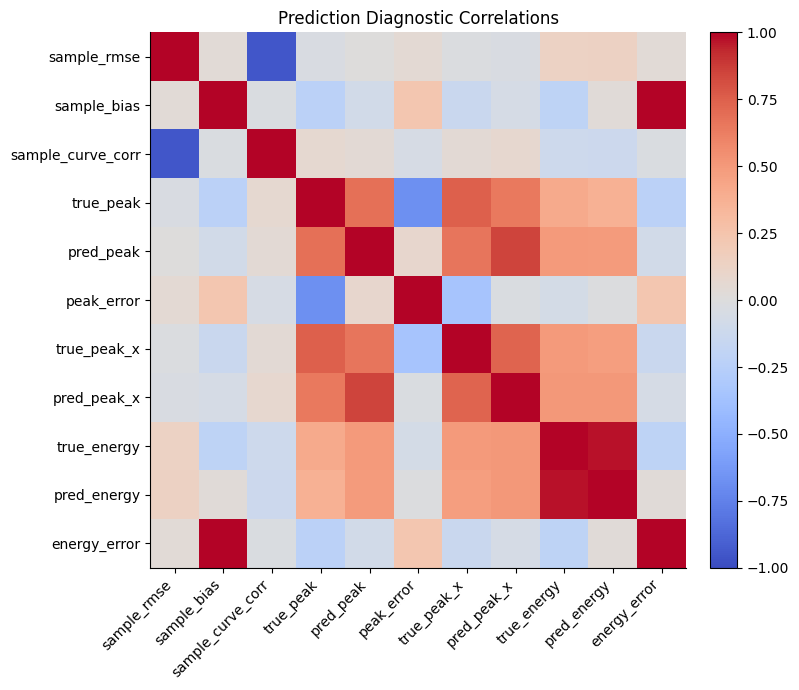

### Diagnostic Correlations

,sample_rmse,sample_bias,sample_curve_corr,true_peak,pred_peak,peak_error,true_peak_x,pred_peak_x,true_energy,pred_energy,energy_error
sample_rmse,1.000000,0.032089,-0.945591,-0.034670,0.002073,0.049288,-0.019562,-0.031350,0.129779,0.140424,0.032091
sample_bias,0.032089,1.000000,-0.028363,-0.230475,-0.082219,0.231050,-0.139158,-0.059149,-0.210579,0.024927,0.999996
sample_curve_corr,-0.945591,-0.028363,1.000000,0.069681,0.045884,-0.048697,0.045527,0.074131,-0.115136,-0.124566,-0.028411
true_peak,-0.034670,-0.230475,0.069681,1.000000,0.681090,-0.676106,0.743012,0.646296,0.413632,0.367543,-0.230752
pred_peak,0.002073,-0.082219,0.045884,0.681090,1.000000,0.078999,0.662665,0.848883,0.493844,0.485275,-0.082144
peak_error,0.049288,0.231050,-0.048697,-0.676106,0.078999,1.000000,-0.344763,-0.025698,-0.066201,-0.012075,0.231504
true_peak_x,-0.019562,-0.139158,0.045527,0.743012,0.662665,-0.344763,1.000000,0.728963,0.496210,0.473988,-0.139190
pred_peak_x,-0.031350,-0.059149,0.074131,0.646296,0.848883,-0.025698,0.728963,1.000000,0.507088,0.504389,-0.058957
true_energy,0.129779,-0.210579,-0.115136,0.413632,0.493844,-0.066201,0.496210,0.507088,1.000000,0.972024,-0.210556
pred_energy,0.140424,0.024927,-0.124566,0.367543,0.485275,-0.012075,0.473988,0.504389,0.972024,1.000000,0.024952


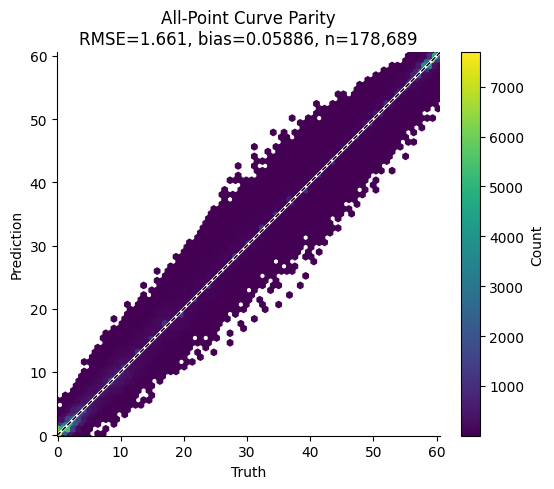

In [10]:
ERROR_CURVE_SAMPLES = 100
ERROR_CURVE_SORT_BY = "rmse"
SHOW_CORRELATION_MATRIX = True
SHOW_CURVE_PARITY = True
CURVE_PARITY_GRIDSIZE = 75
CURVE_PARITY_FIGSIZE = (6, 5)


display_curve_pointwise_summary(
    active_diag,
    data=DAT,
    mode=active_key[0] if active_key is not None else VIEW_MODE,
    max_error_curves=ERROR_CURVE_SAMPLES,
    sort_by=ERROR_CURVE_SORT_BY,
    show_correlation=SHOW_CORRELATION_MATRIX,
)

if SHOW_CURVE_PARITY:
    plot_curve_all_point_parity(
        active_diag,
        gridsize=CURVE_PARITY_GRIDSIZE,
        figsize=CURVE_PARITY_FIGSIZE,
    )


## 9. Sample-Level Error


### Best And Worst Samples By RMSE

,sample,sample_mae,sample_mse,sample_rmse,sample_bias,sample_max_abs_error,sample_curve_corr,true_peak,pred_peak,peak_error,true_peak_x,pred_peak_x,peak_x_error,true_energy,pred_energy,energy_error
575,575,0.383420,0.258971,0.508892,0.061991,1.654398,0.999805,59.654679,59.931981,0.277302,0.018899,0.018299,-0.000600,1.401733,1.405515,0.003783
615,615,0.382099,0.326475,0.571380,0.117473,1.644815,0.999736,60.142451,60.605404,0.462953,0.019799,0.020399,0.000600,1.450117,1.457157,0.007040
427,427,0.457769,0.354918,0.595750,0.140656,1.672980,0.999712,60.413959,60.583032,0.169072,0.020099,0.020399,0.000300,1.422360,1.430844,0.008483
405,405,0.438050,0.389716,0.624272,-0.016541,2.294079,0.999653,59.808496,59.779437,-0.029059,0.015899,0.016799,0.000900,1.387451,1.386414,-0.001037
464,464,0.473338,0.450705,0.671346,-0.330874,1.775337,0.999682,59.843636,59.652924,-0.190712,0.016199,0.016199,0.000000,1.251574,1.231671,-0.019902
694,694,1.598766,9.688200,3.112587,0.309440,14.197035,0.992137,59.811869,59.857877,0.046008,0.017399,0.017699,0.000300,1.287032,1.305604,0.018572
14,14,2.519869,10.716967,3.273678,-0.710351,8.185222,0.990314,60.636331,59.888220,-0.748111,0.018899,0.017399,-0.001500,1.725749,1.682792,-0.042957
510,510,2.235431,10.879134,3.298353,2.235431,10.227842,0.993874,59.759603,61.203596,1.443993,0.018599,0.022195,0.003596,1.661335,1.795678,0.134343
49,49,1.971770,12.609513,3.550988,1.949744,9.227891,0.992029,59.649024,59.719376,0.070353,0.016799,0.016799,0.000000,1.412004,1.529282,0.117279
690,690,2.802698,21.431999,4.629471,-2.748359,14.145678,0.987641,60.070802,60.068720,-0.002082,0.021299,0.018299,-0.002999,1.720277,1.555050,-0.165227


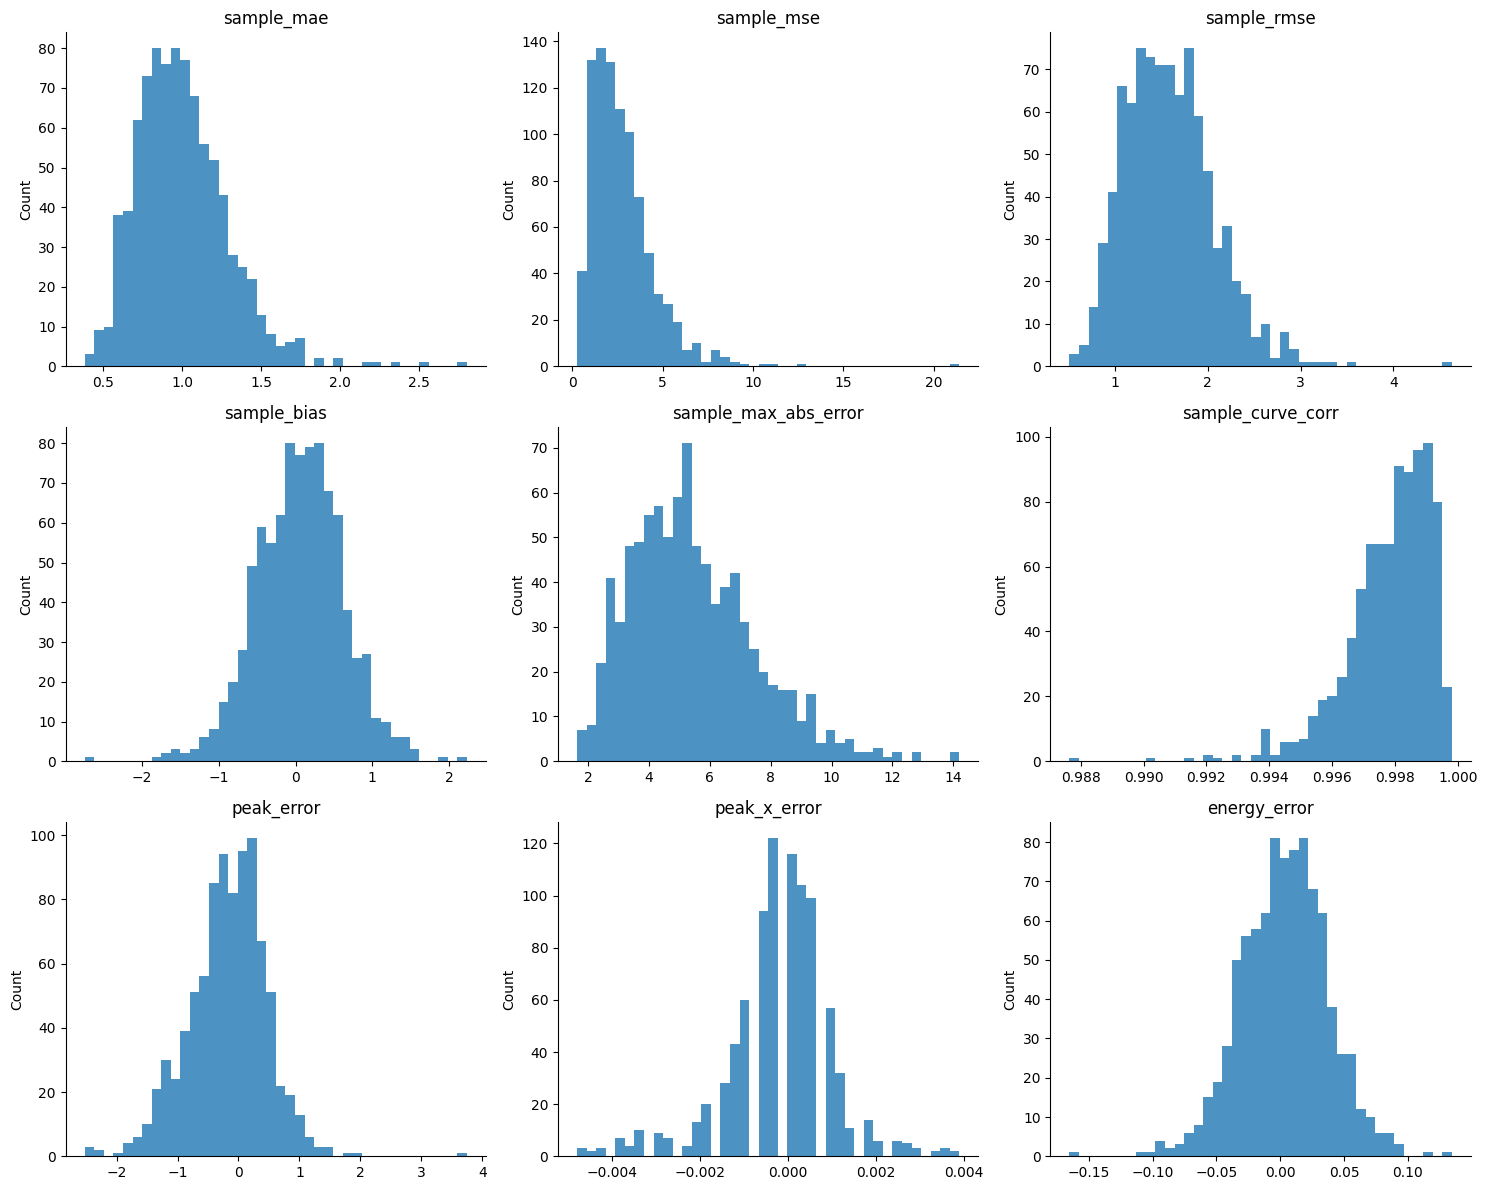

### Sample Metric Summary

,count,mean,std,min,25%,50%,75%,max
sample_mae,889.0,1.000389,0.288636,0.382099,0.797990,0.964041,1.162601,2.802698
sample_mse,889.0,2.758365,1.774857,0.258971,1.541072,2.392496,3.512889,21.431999
sample_rmse,889.0,1.588931,0.483660,0.508892,1.241399,1.546769,1.874270,4.629471
sample_bias,889.0,0.058858,0.565693,-2.748359,-0.326387,0.073999,0.434112,2.235431
sample_max_abs_error,889.0,5.445938,2.051623,1.644815,3.932605,5.176051,6.675865,14.197035
sample_curve_corr,889.0,0.997803,0.001382,0.987641,0.997121,0.998088,0.998814,0.999805
peak_error,889.0,-0.173758,0.642900,-2.523079,-0.560964,-0.125638,0.241277,3.751023
peak_x_error,889.0,-0.000195,0.001216,-0.004798,-0.000600,0.000000,0.000600,0.003900
energy_error,889.0,0.003539,0.034004,-0.165227,-0.019500,0.004307,0.026031,0.134343


In [11]:
SAMPLE_DISTRIBUTION_BINS = 40
SAMPLE_DISTRIBUTION_NCOLS = 3
SAMPLE_TABLE_TOP_N = 5
SAMPLE_DESCRIBE_COLUMNS = [
    "sample_mae",
    "sample_mse",
    "sample_rmse",
    "sample_bias",
    "sample_max_abs_error",
    "sample_curve_corr",
    "peak_error",
    "peak_x_error",
    "energy_error",
]


display_curve_sample_error_summary(
    active_diag,
    bins=SAMPLE_DISTRIBUTION_BINS,
    ncols=SAMPLE_DISTRIBUTION_NCOLS,
    top_n=SAMPLE_TABLE_TOP_N,
    columns=SAMPLE_DESCRIBE_COLUMNS,
)


## 10. Initial Slope, Peak, And Energy Agreement


### Initial Slope Summary

,metric,value
0,window_start_idx,0.000000
1,window_end_idx,16.000000
2,window_start_x,0.000000
3,window_end_x,0.004800
4,window_points,17.000000
5,slope_correlation,0.224398
6,slope_mae,11.864225
7,slope_rmse,14.983502
8,slope_bias,0.383226
9,slope_median_abs_percent_error,0.138494


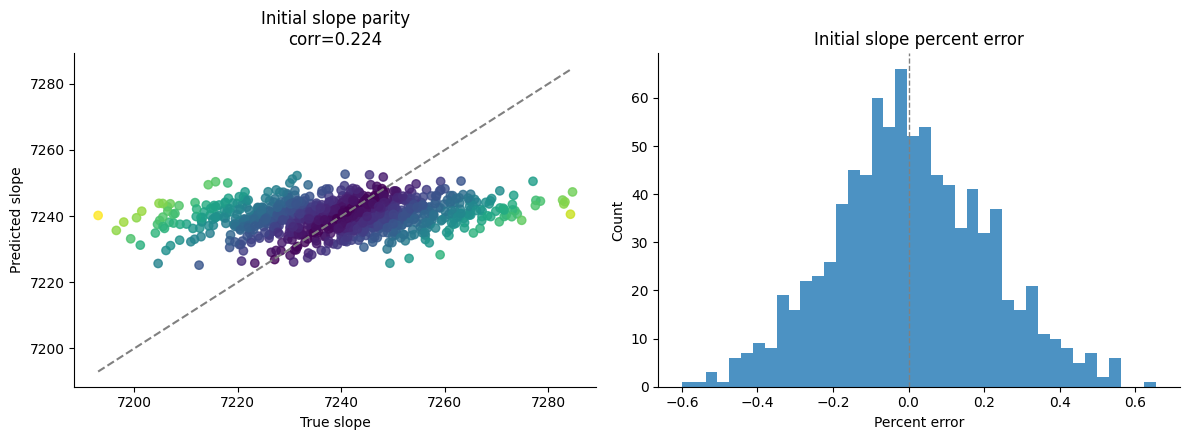

### Worst Initial Slope Samples

,sample,true_slope,pred_slope,slope_error,slope_percent_error,abs_percent_error
381,381,7193.011164,7240.196788,47.185624,0.655993,0.655993
630,630,7284.275072,7240.569938,-43.705134,-0.599993,0.599993
849,849,7197.962340,7238.198936,40.236595,0.559000,0.559000
627,627,7201.442772,7241.489494,40.046722,0.556093,0.556093
327,327,7196.525764,7235.672803,39.147039,0.543971,0.543971


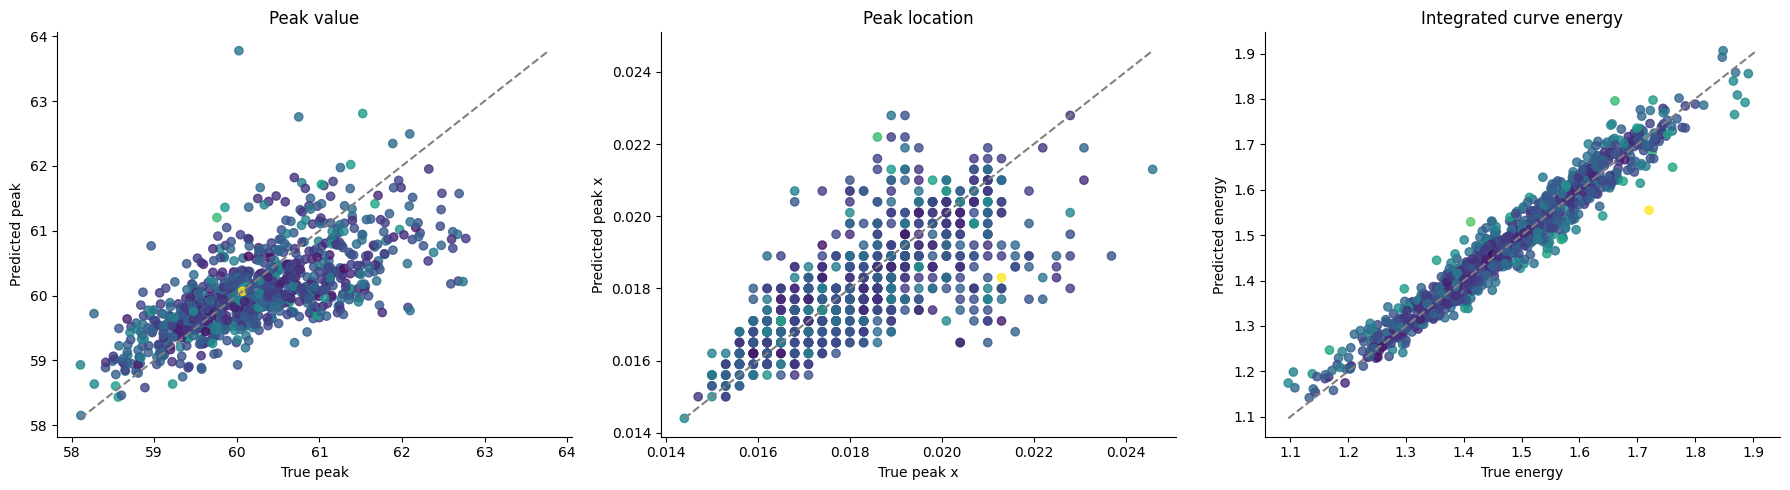

In [12]:
SHOW_INITIAL_SLOPE = True
INITIAL_SLOPE_WINDOW_FRACTION = 0.08
INITIAL_SLOPE_X_THRESHOLD = None
INITIAL_SLOPE_MIN_POINTS = 3
INITIAL_SLOPE_TOP_N = 5
SHOW_PEAK_ENERGY = True


if SHOW_INITIAL_SLOPE:
    slope_metrics_df, slope_summary = display_curve_initial_slope_summary(
        active_diag,
        window_fraction=INITIAL_SLOPE_WINDOW_FRACTION,
        x_threshold=INITIAL_SLOPE_X_THRESHOLD,
        min_points=INITIAL_SLOPE_MIN_POINTS,
        top_n=INITIAL_SLOPE_TOP_N,
    )

if SHOW_PEAK_ENERGY:
    display_curve_peak_energy_summary(active_diag)


## 11. Zone Metrics


### Zone Metrics

,zone,start_idx,end_idx,x_start,x_end,mae,mse,rmse,bias,true_std_mean,pred_std_mean,collapse_ratio
0,elastic,0,67,0.000000,0.019799,0.256975,0.240616,0.490527,0.032828,0.559820,0.411505,0.735065
1,peak_region,67,134,0.020099,0.039848,1.966936,6.878655,2.622719,0.178464,7.099680,6.737261,0.948953
2,post_peak,134,201,0.040147,0.059936,0.777256,1.155824,1.075093,-0.034718,2.338833,2.151546,0.919923


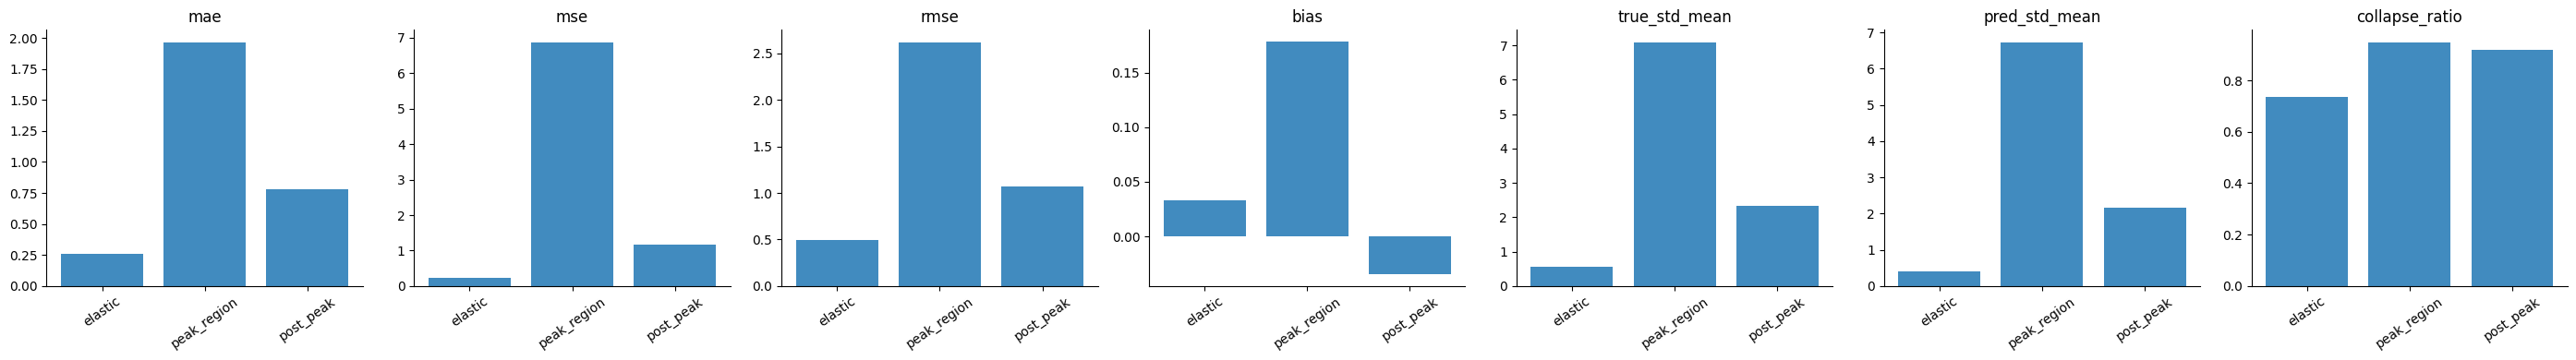

In [13]:
SHOW_ZONE_METRICS = True


if SHOW_ZONE_METRICS:
    display_curve_zone_summary(active_diag)


## 12. Selected Curve Examples


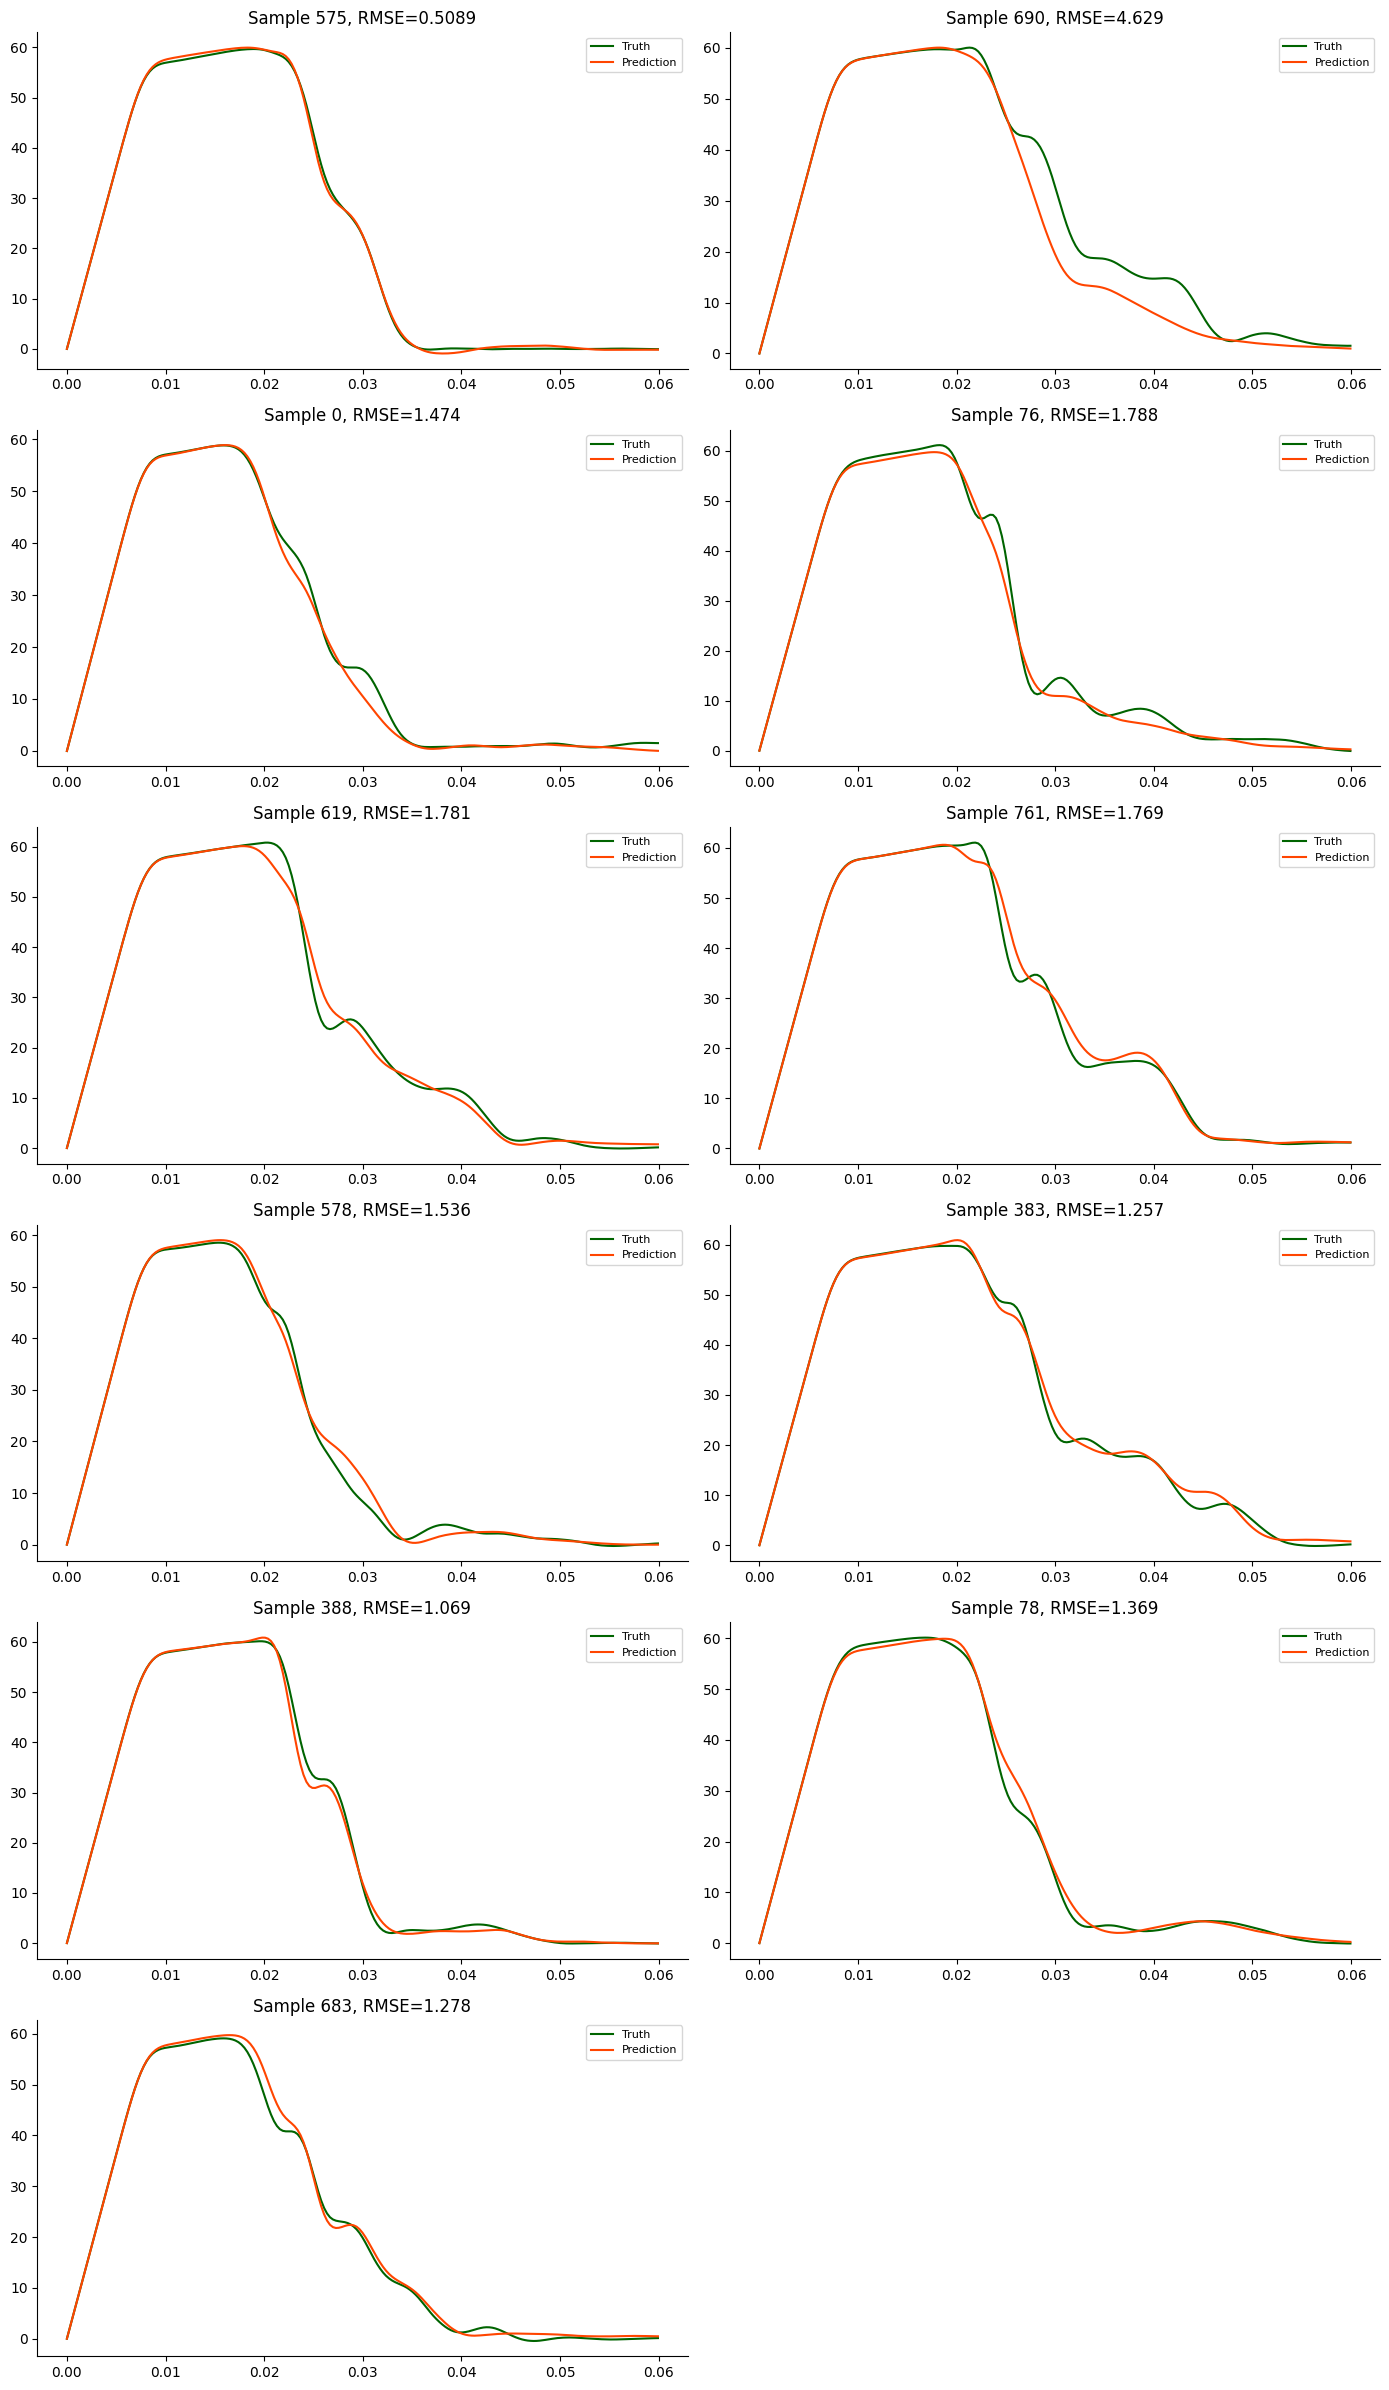

(<Figure size 1400x2400 with 12 Axes>,
 array([<Axes: title={'center': 'Sample 575, RMSE=0.5089'}>,
        <Axes: title={'center': 'Sample 690, RMSE=4.629'}>,
        <Axes: title={'center': 'Sample 0, RMSE=1.474'}>,
        <Axes: title={'center': 'Sample 76, RMSE=1.788'}>,
        <Axes: title={'center': 'Sample 619, RMSE=1.781'}>,
        <Axes: title={'center': 'Sample 761, RMSE=1.769'}>,
        <Axes: title={'center': 'Sample 578, RMSE=1.536'}>,
        <Axes: title={'center': 'Sample 383, RMSE=1.257'}>,
        <Axes: title={'center': 'Sample 388, RMSE=1.069'}>,
        <Axes: title={'center': 'Sample 78, RMSE=1.369'}>,
        <Axes: title={'center': 'Sample 683, RMSE=1.278'}>, <Axes: >],
       dtype=object))

In [14]:
SELECTED_SAMPLE = 0
RANDOM_SAMPLE_COUNT = 8
RANDOM_SEED = 42
EXAMPLE_RANK_BY = "sample_rmse"
EXAMPLE_NCOLS = 2


display_curve_sample_examples(
    active_diag,
    selected_sample=SELECTED_SAMPLE,
    random_count=RANDOM_SAMPLE_COUNT,
    random_seed=RANDOM_SEED,
    rank_by=EXAMPLE_RANK_BY,
    ncols=EXAMPLE_NCOLS,
)


## 13. Training Loss History


,mode,epoch,train_loss,val_loss
0,UT,1,0.062021,0.058647
1,UT,2,0.051953,0.047615
2,UT,3,0.048563,0.046906
3,UT,4,0.046260,0.043493
4,UT,5,0.043667,0.040946


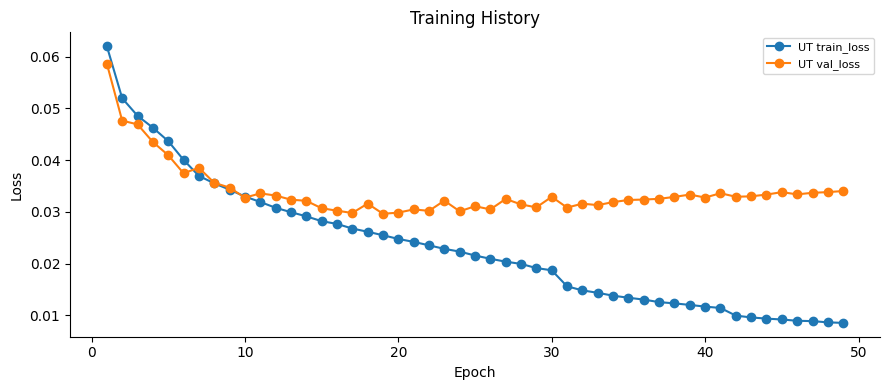

(<Figure size 900x400 with 1 Axes>,
 <Axes: title={'center': 'Training History'}, xlabel='Epoch', ylabel='Loss'>)

In [15]:
LOSS_HISTORY_METRICS = ["train_loss", "val_loss"]
LOSS_HISTORY_FIGSIZE = (9, 4)


loss_history = loaded.get("loss_history")
if loss_history is not None and hasattr(loss_history, "empty") and not loss_history.empty:
    display(loss_history.head())
plot_loss_history(loss_history, metrics=LOSS_HISTORY_METRICS, figsize=LOSS_HISTORY_FIGSIZE)


## 14. Loss Component Breakdown


In [16]:
SHOW_LOSS_COMPONENTS = True


if SHOW_LOSS_COMPONENTS:
    loss_components_df = display_curve_loss_component_breakdown(MOD, active_diag, active_key=active_key)


MODEL is not loaded, so loss components cannot be evaluated.
